In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_raw = pd.read_csv('sri_lanka_irrigation_dataset.csv') 
print(f"Shape: {dataset_raw.shape} → {dataset_raw.shape[0]} records, {dataset_raw.shape[1]} features") 
pd.set_option('display.max_columns', None) 
dataset_raw.head()

Shape: (10000, 28) → 10000 records, 28 features


,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm,Gross_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,13.2,3.77,0.70,0.0,NaN
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,0.0,3.87,0.90,0.0,NaN
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,0.0,2.79,1.05,0.0,NaN
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,0.0,3.09,0.75,0.0,NaN
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,62.4,4.43,1.05,2.8,3.1


# We drop these columns because they are not necessary to predict the Net Irrigation Requirement (mm).

In [3]:
df_raw = dataset_raw.drop(["Gross_Irrigation_Requirement_mm", "Previous_Irrigation_mm"], axis=1)

In [4]:
df_raw

,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70,0.0
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90,0.0
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05,0.0
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75,0.0
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2498,Nuwara Eliya,Wet,Maha,Chili,Late-season,30,Clay,6.94,30.48,1.01,1.02,26.3,22.8,24.6,83.3,189.4,6.3,8.6,Furrow/Surface,Rainfed,0.59,No,2.55,0.90,0.0
9996,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Initial,20,Sandy,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,Drip,Minor Tank,0.59,No,4.84,1.05,38.6
9997,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Development,30,Sandy,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,Drip,Minor Tank,0.59,No,5.27,1.10,140.4
9998,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Mid-season,40,Sandy,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,Drip,Minor Tank,0.59,No,5.37,1.20,119.2


# Here We inspect the dataset at this stage to detect "dirty" (inconsistent/corrupted) entries and identify any null (missing) values across all columns.

In [5]:
# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print(f"Wrong data types and dirty entries have been corrected.\n")

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
Field_Cycle_ID,int64,0,0.000000,2500,"[0, 1, 2]"
District,object,0,0.000000,25,"['Kalutara', 'Monaragala', 'Galle']"
Climate_Zone,object,0,0.000000,3,"['Wet', 'Intermediate', 'Dry']"
Season,object,0,0.000000,2,"['Maha', 'Yala']"
Crop_Type,object,0,0.000000,6,"['Big Onion', 'Paddy (Rice)', 'Tomato']"
Crop_Growth_Stage,object,0,0.000000,4,"['Initial', 'Development', 'Mid-season']"
Stage_Duration_days,int64,0,0.000000,11,"[15, 25, 35]"
Soil_Type,object,0,0.000000,4,"['Sandy Loam', 'Sandy', 'Loamy']"
Soil_pH,float64,0,0.000000,350,"[5.95, 5.77, 5.9]"
Soil_Moisture_pct,float64,0,0.000000,2867,"[15.2, 18.5, 18.9]"


Wrong data types and dirty entries have been corrected.



# The 'District' column is removed for two main reasons.

## 1.The specific environmental factors influenced by geography—such as climate, soil type, and rainfall—are already captured as precise, individual features. This makes the regional label redundant.

## 2. 'District' is a categorical variable with 25 unique values. Encoding it would introduce 25 new features, unnecessarily increasing dataset dimensionality and model complexity."

In [6]:
df_raw = df_raw.drop(["District"], axis=1, errors='ignore')

# I am doing this step bacuse to make sure the feature crops Coefficient (Kc) has the informations of  the featueres Crop_Type and Crop_Growth_Stage

In [7]:
# Create a pivot table showing the average, min, and max Kc values 
# broken down by each crop type and its specific growth stage
kc_profile = dataset_raw.groupby(['Crop_Type', 'Crop_Growth_Stage'])['Crop_Coefficient_Kc'].agg(
    Mean_Kc='mean',
    Min_Kc='min',
    Max_Kc='max',
    Record_Count='count'
).reset_index()

# Sort logically to keep crop lifecycle stages cohesive
print("--- Crop Coefficient (Kc) Breakdown by Growth Stage ---")
print(kc_profile.to_string(index=False))

--- Crop Coefficient (Kc) Breakdown by Growth Stage ---
   Crop_Type Crop_Growth_Stage  Mean_Kc  Min_Kc  Max_Kc  Record_Count
   Big Onion       Development     0.90    0.90    0.90           428
   Big Onion           Initial     0.70    0.70    0.70           428
   Big Onion       Late-season     0.75    0.75    0.75           428
   Big Onion        Mid-season     1.05    1.05    1.05           428
       Chili       Development     0.85    0.85    0.85           400
       Chili           Initial     0.60    0.60    0.60           400
       Chili       Late-season     0.90    0.90    0.90           400
       Chili        Mid-season     1.05    1.05    1.05           400
  Green Gram       Development     0.75    0.75    0.75           435
  Green Gram           Initial     0.40    0.40    0.40           435
  Green Gram       Late-season     0.40    0.40    0.40           435
  Green Gram        Mid-season     1.05    1.05    1.05           435
       Maize       Development    

In [8]:
df=df_raw.copy()

# Removing the Duplicate by rows and columns

In [9]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")

--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 10000 rows, 25 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 10000 rows, 25 features



# Analyze the Target Variable: Net_Irrigation_Requirement_mm

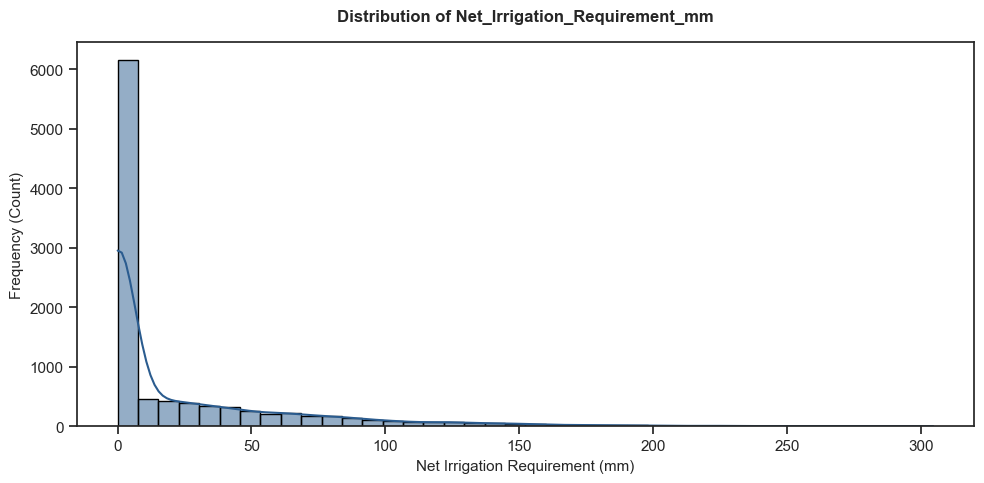

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting window style
plt.figure(figsize=(10, 5))
sns.set_theme(style="ticks")

# Plot the target variable distribution
sns.histplot(
    data=df, 
    x='Net_Irrigation_Requirement_mm', 
    bins=40, 
    color="#2b5c8f", 
    edgecolor="black", 
    kde=True
)

# Label the chart layout cleanly
plt.title("Distribution of Net_Irrigation_Requirement_mm", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Net Irrigation Requirement (mm)", fontsize=11)
plt.ylabel("Frequency (Count)", fontsize=11)

# Render the plot
plt.tight_layout()
plt.show()

### The histogram reveals that Net_Irrigation_Requirement_mm is heavily zero-inflated with a highly skewed right tail. Because standard regression algorithms struggle with this mixture of exact zeros and continuous positive values, we will implement a -- Hurdle Model -- architecture to optimize predictive performance.

In [14]:
# Save the DataFrame to a CSV file without the index column
df.to_csv('preprocessed_sl_irrigation_water.csv', index=False)
print("DataFrame saved successfully!")

DataFrame saved successfully!
